In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


# 预处理

In [2]:
# 加载FashionMNIST数据集
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将PIL图像或numpy数组转换为tensor,ToTensor会自动将图像转换为tensor，并归一化到[0,1]范围
    transforms.Normalize((0.2860,), (0.3530,))  # 标准化到[-1, 1]范围
])

# 下载并加载训练集
train_dataset = datasets.FashionMNIST(
    root='./data',  # 数据存储路径
    train=True,     # 加载训练集
    download=True,  # 如果数据不存在则下载
    transform=transform
)

# 下载并加载测试集
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,    # 加载测试集
    download=True,
    transform=transform
)

# 打印数据集信息
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

# lables在这个路径https://github.com/zalandoresearch/fashion-mnist
# FashionMNIST类别标签
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")


训练集大小: 60000
测试集大小: 10000
类别数量: 10
类别标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
    num_workers=2  # 使用多进程加载数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
    num_workers=2
)

# 搭建DNN

In [4]:
import torch
import torch.nn as nn

class DNN(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10, hidden_size=100, num_hidden_layers=19):
        """
        构建多层感知机（DNN）模型，结构包含Dropout防止过拟合

        参数说明:
            input_size: 输入特征数，MNIST/FashionMNIST为28*28=784
            num_classes: 分类类别数，FashionMNIST为10
            hidden_size: 每个隐藏层的神经元数
            num_hidden_layers: 隐藏层总数
        """
        super(DNN, self).__init__()

        layers = []
        
        # 输入层到第1隐藏层
        layers.append(nn.Linear(input_size, hidden_size))  # 输入层到第一个隐藏层的线性变换
        layers.append(nn.ReLU())                           # 激活函数ReLU, 增强非线性表达能力
        layers.append(nn.AlphaDropout(p=0.2))              # AlphaDropout, 随机丢弃神经元防止过拟合, p=0.2表示20%

        # 多个隐藏层（除第一层外）
        # 由于第一层已经加了，循环添加剩余的隐藏层
        for i in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))  # 隐藏层间线性变换
            layers.append(nn.ReLU())                            # 每个隐藏层后接ReLU
        
        # 输出层（隐藏层->类别数，对应分类任务）
        layers.append(nn.Linear(hidden_size, num_classes))
        
        # nn.Sequential 可以将层按顺序组合，便于前向传播调用
        self.layers = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        定义前向传播过程，输入x为(batch_size, 1, 28, 28)
        返回logits（未归一化的类别得分）
        """
        x = x.view(x.size(0), -1)  # 展平输入张量 (batch_size, 28*28)
        x = self.layers(x)         # 顺序经过各层
        return x

# 创建DNN模型实例
model = DNN(input_size=28*28, num_classes=10)

# 打印模型结构详情，便于检查
print(model)

# 统计并打印模型参数总数（可了解复杂度）
print(f"\n模型参数总数: {sum(p.numel() for p in model.parameters())}")


DNN(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): AlphaDropout(p=0.2, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=100, bias=True)
    (6): ReLU()
    (7): Linear(in_features=100, out_features=100, bias=True)
    (8): ReLU()
    (9): Linear(in_features=100, out_features=100, bias=True)
    (10): ReLU()
    (11): Linear(in_features=100, out_features=100, bias=True)
    (12): ReLU()
    (13): Linear(in_features=100, out_features=100, bias=True)
    (14): ReLU()
    (15): Linear(in_features=100, out_features=100, bias=True)
    (16): ReLU()
    (17): Linear(in_features=100, out_features=100, bias=True)
    (18): ReLU()
    (19): Linear(in_features=100, out_features=100, bias=True)
    (20): ReLU()
    (21): Linear(in_features=100, out_features=100, bias=True)
    (22): ReLU()
    (23): Linear(in_features=100, out_features=100, bias

In [5]:
# 验证模型前向计算
# 创建一个随机输入张量，模拟MNIST图片数据
batch_size = 32
input_tensor = torch.randn(batch_size, 1, 28, 28)  # (batch_size, channels, height, width)

print(f"输入张量形状: {input_tensor.shape}")

# 前向传播
with torch.no_grad():  # 不需要计算梯度
    output = model(input_tensor)
    
print(f"输出张量形状: {output.shape}")
print(f"输出张量示例 (前5个样本的前5个类别概率):")
print(output[:5, :5])

# 验证输出维度是否正确
assert output.shape == (batch_size, 10), f"期望输出形状为 ({batch_size}, 10), 但得到 {output.shape}"
print("\n✅ 模型前向计算验证成功！")


输入张量形状: torch.Size([32, 1, 28, 28])
输出张量形状: torch.Size([32, 10])
输出张量示例 (前5个样本的前5个类别概率):
tensor([[ 0.0858,  0.0040,  0.0850, -0.0301,  0.0310],
        [ 0.0858,  0.0040,  0.0850, -0.0301,  0.0310],
        [ 0.0858,  0.0040,  0.0850, -0.0301,  0.0310],
        [ 0.0858,  0.0040,  0.0850, -0.0301,  0.0310],
        [ 0.0858,  0.0040,  0.0850, -0.0301,  0.0310]])

✅ 模型前向计算验证成功！


In [11]:
for batch in train_loader:
    inputs, targets = batch
    print(inputs.shape)
    print(targets.shape)
    break


torch.Size([32, 1, 28, 28])
torch.Size([32])


In [12]:
# 导入训练模块
from wangdao_train import Trainer

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 初始化损失函数
criterion = torch.nn.CrossEntropyLoss()

# 初始化优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 初始化早停
early_stopping_kwargs = {
    'patience': 10,
    'min_delta': 0.001,
    'mode': 'max'
}

# 创建训练器
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500,
    # early_stopping_kwargs=early_stopping_kwargs
)

# 开始训练
print("开始训练...")
trainer.train(num_epochs=20)


使用设备: cpu
开始训练...
[Step 500] Val Loss: 1.0309 Val Acc: 0.5585
[Step 1000] Val Loss: 0.8690 Val Acc: 0.6610
[Step 1500] Val Loss: 0.7120 Val Acc: 0.7148
Epoch [1/20]  Train Loss: 1.0066  Train Acc: 0.5819
[Step 2000] Val Loss: 0.8026 Val Acc: 0.6959
[Step 2500] Val Loss: 1.2727 Val Acc: 0.5262
[Step 3000] Val Loss: 0.9153 Val Acc: 0.6549
[Step 3500] Val Loss: 1.0659 Val Acc: 0.5876
Epoch [2/20]  Train Loss: 0.8684  Train Acc: 0.6677
[Step 4000] Val Loss: 0.8935 Val Acc: 0.6493
[Step 4500] Val Loss: 0.8439 Val Acc: 0.6940
[Step 5000] Val Loss: 1.2665 Val Acc: 0.4685
[Step 5500] Val Loss: 0.8052 Val Acc: 0.7021
Epoch [3/20]  Train Loss: 0.9060  Train Acc: 0.6446
[Step 6000] Val Loss: 0.9475 Val Acc: 0.6117
[Step 6500] Val Loss: 0.7538 Val Acc: 0.7034
[Step 7000] Val Loss: 0.9065 Val Acc: 0.6580
[Step 7500] Val Loss: 0.8151 Val Acc: 0.6849
Epoch [4/20]  Train Loss: 0.8515  Train Acc: 0.6754
[Step 8000] Val Loss: 0.8684 Val Acc: 0.6648
[Step 8500] Val Loss: 0.7007 Val Acc: 0.7433
[Step 9000

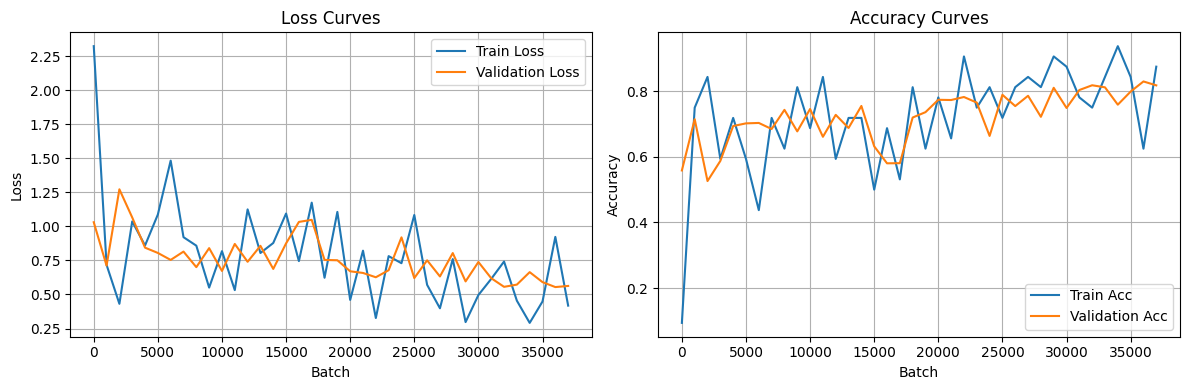

In [13]:
trainer.plot_curves()

## 2. 默写上课讲解的Sigmoid, ReLu, Elu, Selu激活函数特点

### Sigmoid激活函数
- 函数输出范围为(0, 1)，常用于二分类输出层。
- 优点：可以平滑地将输出映射为概率。
- 缺点：在极端值处容易梯度消失，导致训练缓慢。

### ReLU激活函数
- 输入大于0时输出等于输入，小于等于0时输出为0。
- 优点：计算简单，有效缓解梯度消失问题。
- 缺点：部分神经元可能“死亡”（输出恒为0）。

### ELU激活函数
- 输入大于0时等于输入，小于等于0时为带α（alpha）系数的指数函数。
- 优点：在输入为负时能输出负数，使输出均值接近0，有助于加快收敛速度。
- 相比ReLU，ELU提供了更好的归一化特性。

### SELU激活函数
- 在ELU的基础上进行了缩放，具备自归一化特性。
- 能自动将输出缩放到均值为0、方差为1，有助于深层神经网络更稳定地训练。
